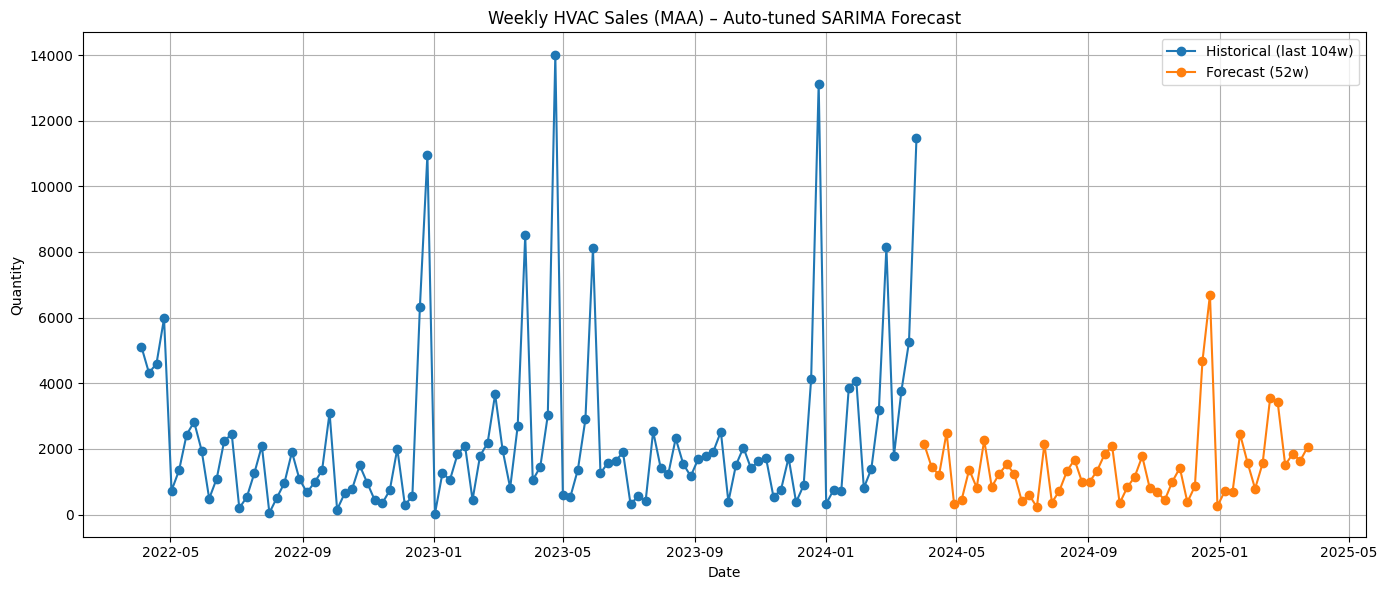

(((0, 0, 2), (0, 1, 1, 52)),
 np.float64(564.539386394398),
          Date  Forecast_Quantity  Lower_CI  Upper_CI
 0  2024-04-01             2161.6     127.2   36467.8
 1  2024-04-08             1456.1      75.6   27730.1
 2  2024-04-15             1207.2      57.1   25121.3
 3  2024-04-22             2500.7     119.3   52020.4
 4  2024-04-29              313.2      14.1    6532.6
 5  2024-05-06              451.7      20.8    9413.3
 6  2024-05-13             1373.3      65.1   28575.6
 7  2024-05-20              821.2      38.5   17095.5
 8  2024-05-27             2268.0     108.1   47180.4
 9  2024-06-03              842.6      39.6   17540.3
 10 2024-06-10             1248.0      59.1   25971.5
 11 2024-06-17             1529.5      72.6   31823.9,
 '../data/maa_weekly_autoarima_forecast_52w.csv')

In [2]:
# Option A: Auto-ARIMA style tuning (constrained grid) for weekly data, exogenous-ready pipeline.
# We'll search a small grid over (p,d,q)(P,D,Q,s) to select by AIC and forecast 52 weeks.
import pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings, itertools, os
from statsmodels.tsa.statespace.sarimax import SARIMAX
warnings.filterwarnings("ignore")

# --- Load data (file if available; otherwise fallback to raw pasted text) ---
csv_path = "/mnt/data/branch_wise_weekly.csv"
try:
    df = pd.read_csv(csv_path, parse_dates=["Date"])
except Exception:
    raw = r"""Branch,Date,Quantity
MAA,2019-04-01,417.0
MAA,2019-04-08,1779.0
MAA,2019-04-15,3159.5
MAA,2019-04-22,3757.0
MAA,2019-04-29,5210.0
MAA,2019-05-06,2708.0
MAA,2019-05-13,2167.0
MAA,2019-05-20,2345.0
MAA,2019-05-27,3479.5
MAA,2019-06-03,825.0
MAA,2019-06-10,1510.0
MAA,2019-06-17,1996.5
MAA,2019-06-24,2169.5
MAA,2019-07-01,323.0
MAA,2019-07-08,1207.0
MAA,2019-07-15,1073.0
MAA,2019-07-22,997.5
MAA,2019-07-29,1281.5
MAA,2019-08-05,424.0
MAA,2019-08-12,720.0
MAA,2019-08-19,1046.5
MAA,2019-08-26,2027.0
MAA,2019-09-02,466.5
MAA,2019-09-09,710.5
MAA,2019-09-16,951.0
MAA,2019-09-23,3303.0
MAA,2019-09-30,600.5
MAA,2019-10-07,561.5
MAA,2019-10-14,585.5
MAA,2019-10-21,997.5
MAA,2019-10-28,2149.5
MAA,2019-11-04,304.5
MAA,2019-11-11,324.0
MAA,2019-11-18,516.5
MAA,2019-11-25,1541.5
MAA,2019-12-02,619.5
MAA,2019-12-09,524.0
MAA,2019-12-16,228.5
MAA,2019-12-23,3103.0
MAA,2019-12-30,2015.0
MAA,2020-01-06,543.0
MAA,2020-01-13,942.5
MAA,2020-01-20,819.5
MAA,2020-01-27,3002.0
MAA,2020-02-03,583.0
MAA,2020-02-10,1555.0
MAA,2020-02-17,3287.5
MAA,2020-02-24,7378.5
MAA,2020-03-02,2566.5
MAA,2020-03-09,1553.5
MAA,2020-03-16,1087.5
MAA,2020-05-11,2337.0
MAA,2020-05-18,2464.0
MAA,2020-05-25,4950.0
MAA,2020-06-01,1768.5
MAA,2020-06-08,2387.0
MAA,2020-06-15,865.0
MAA,2020-06-22,485.0
MAA,2020-06-29,221.0
MAA,2020-07-06,478.0
MAA,2020-07-13,413.0
MAA,2020-07-20,661.0
MAA,2020-07-27,2477.0
MAA,2020-08-03,228.0
MAA,2020-08-10,133.5
MAA,2020-08-17,525.5
MAA,2020-08-24,2460.0
MAA,2020-08-31,812.0
MAA,2020-09-07,824.5
MAA,2020-09-14,1083.0
MAA,2020-09-21,1964.0
MAA,2020-09-28,2087.0
MAA,2020-10-05,555.0
MAA,2020-10-12,368.0
MAA,2020-10-19,757.0
MAA,2020-10-26,2824.5
MAA,2020-11-02,282.5
MAA,2020-11-09,526.5
MAA,2020-11-16,516.5
MAA,2020-11-23,1980.0
MAA,2020-11-30,1016.0
MAA,2020-12-07,368.0
MAA,2020-12-14,1140.0
MAA,2020-12-21,4431.0
MAA,2020-12-28,2782.0
MAA,2021-01-04,905.0
MAA,2021-01-11,377.0
MAA,2021-01-18,589.0
MAA,2021-01-25,3755.0
MAA,2021-02-01,969.5
MAA,2021-02-08,2129.0
MAA,2021-02-15,1243.5
MAA,2021-02-22,4109.0
MAA,2021-03-01,728.0
MAA,2021-03-08,1050.0
MAA,2021-03-15,3564.0
MAA,2021-03-22,1543.0
MAA,2021-03-29,3505.0
MAA,2021-04-05,6937.0
MAA,2021-04-12,5811.0
MAA,2021-04-19,2483.5
MAA,2021-04-26,4030.5
MAA,2021-05-03,427.0
MAA,2021-05-10,6.0
MAA,2021-05-17,277.0
MAA,2021-05-31,426.0
MAA,2021-06-07,248.0
MAA,2021-06-14,882.0
MAA,2021-06-21,1443.5
MAA,2021-06-28,1613.5
MAA,2021-07-05,824.0
MAA,2021-07-12,675.0
MAA,2021-07-17,815.5
MAA,2021-07-26,1994.5
MAA,2021-08-02,417.0
MAA,2021-08-09,1462.0
MAA,2021-08-16,1483.5
MAA,2021-08-23,1095.0
MAA,2021-08-30,1178.0
MAA,2021-09-06,784.5
MAA,2021-09-13,1606.0
MAA,2021-09-20,1715.0
MAA,2021-09-27,1741.0
MAA,2021-10-04,445.5
MAA,2021-10-11,749.5
MAA,2021-10-18,894.0
MAA,2021-10-25,2312.5
MAA,2021-11-01,571.0
MAA,2021-11-08,356.0
MAA,2021-11-15,360.0
MAA,2021-11-22,1275.5
MAA,2021-11-29,1242.0
MAA,2021-12-06,434.0
MAA,2021-12-13,2886.0
MAA,2021-12-20,5258.0
MAA,2021-12-27,3256.5
MAA,2022-01-03,1180.0
MAA,2022-01-10,405.5
MAA,2022-01-17,366.0
MAA,2022-01-24,910.0
MAA,2022-01-31,374.0
MAA,2022-02-07,519.0
MAA,2022-02-14,1212.0
MAA,2022-02-21,5096.5
MAA,2022-02-28,1881.5
MAA,2022-03-07,945.0
MAA,2022-03-14,1125.5
MAA,2022-03-21,7748.0
MAA,2022-03-28,597.0
MAA,2022-04-04,5109.5
MAA,2022-04-11,4314.5
MAA,2022-04-18,4603.0
MAA,2022-04-25,5975.5
MAA,2022-05-02,731.0
MAA,2022-05-09,1352.5
MAA,2022-05-16,2437.0
MAA,2022-05-23,2823.0
MAA,2022-05-30,1950.0
MAA,2022-06-06,487.5
MAA,2022-06-13,1097.0
MAA,2022-06-20,2250.0
MAA,2022-06-27,2449.5
MAA,2022-07-04,200.0
MAA,2022-07-11,532.0
MAA,2022-07-18,1263.0
MAA,2022-07-25,2094.5
MAA,2022-08-01,53.0
MAA,2022-08-08,516.0
MAA,2022-08-15,966.0
MAA,2022-08-22,1908.5
MAA,2022-08-29,1072.0
MAA,2022-09-05,676.0
MAA,2022-09-12,981.5
MAA,2022-09-19,1345.5
MAA,2022-09-26,3101.0
MAA,2022-10-03,153.0
MAA,2022-10-10,644.5
MAA,2022-10-17,783.0
MAA,2022-10-24,1502.0
MAA,2022-10-31,969.0
MAA,2022-11-07,440.0
MAA,2022-11-14,343.0
MAA,2022-11-21,741.5
MAA,2022-11-28,2009.0
MAA,2022-12-05,301.0
MAA,2022-12-12,553.0
MAA,2022-12-19,6310.0
MAA,2022-12-26,10957.5
MAA,2023-01-02,25.0
MAA,2023-01-09,1266.0
MAA,2023-01-16,1059.0
MAA,2023-01-23,1837.0
MAA,2023-01-30,2103.5
MAA,2023-02-06,449.0
MAA,2023-02-13,1792.5
MAA,2023-02-20,2179.5
MAA,2023-02-27,3664.0
MAA,2023-03-06,1964.0
MAA,2023-03-13,815.0
MAA,2023-03-20,2697.5
MAA,2023-03-27,8506.0
MAA,2023-04-03,1050.0
MAA,2023-04-10,1452.5
MAA,2023-04-17,3023.0
MAA,2023-04-24,13993.0
MAA,2023-05-01,610.5
MAA,2023-05-08,540.0
MAA,2023-05-15,1373.5
MAA,2023-05-22,2902.0
MAA,2023-05-29,8112.0
MAA,2023-06-05,1260.0
MAA,2023-06-12,1585.0
MAA,2023-06-19,1635.0
MAA,2023-06-26,1893.5
MAA,2023-07-03,314.0
MAA,2023-07-10,566.0
MAA,2023-07-17,409.0
MAA,2023-07-24,2536.0
MAA,2023-07-31,1428.5
MAA,2023-08-07,1223.5
MAA,2023-08-14,2322.0
MAA,2023-08-21,1542.0
MAA,2023-08-28,1170.0
MAA,2023-09-04,1702.0
MAA,2023-09-11,1795.0
MAA,2023-09-18,1922.5
MAA,2023-09-25,2526.0
MAA,2023-10-02,391.0
MAA,2023-10-09,1505.0
MAA,2023-10-16,2043.0
MAA,2023-10-23,1411.0
MAA,2023-10-30,1620.0
MAA,2023-11-06,1727.0
MAA,2023-11-13,532.0
MAA,2023-11-20,764.0
MAA,2023-11-27,1733.5
MAA,2023-12-04,378.0
MAA,2023-12-11,893.0
MAA,2023-12-18,4139.5
MAA,2023-12-25,13125.0
MAA,2024-01-01,334.0
MAA,2024-01-08,758.5
MAA,2024-01-15,706.5
MAA,2024-01-22,3859.5
MAA,2024-01-29,4085.0
MAA,2024-02-05,811.5
MAA,2024-02-12,1392.5
MAA,2024-02-19,3183.5
MAA,2024-02-26,8144.5
MAA,2024-03-04,1781.0
MAA,2024-03-11,3776.5
MAA,2024-03-18,5251.5
MAA,2024-03-25,11480.5"""
    from io import StringIO
    df = pd.read_csv(StringIO(raw), parse_dates=["Date"])

df = df[df["Branch"]=="MAA"][["Date","Quantity"]].sort_values("Date")
df.set_index("Date", inplace=True)

# --- Ensure continuous weekly index (keep same weekday as first record) ---
start = df.index.min()
weekday = start.weekday()
full_index = pd.date_range(start=start, end=df.index.max(), freq=pd.offsets.Week(weekday=weekday))
df = df.reindex(full_index)
df.index.name = "Date"
# Prefer carrying forward small inventory/reporting gaps rather than hard zeros
df["Quantity"] = df["Quantity"].fillna(0.0)

# --- Transform ---
y = np.log1p(df["Quantity"].astype(float))

# --- Auto-ARIMA style constrained search ---
s = 52  # weekly seasonality ~ yearly
pdq = [(p,d,q) for p in [0,1,2] for d in [0,1] for q in [0,1,2]]
PDQ = [(P,1,Q, s) for P in [0,1] for Q in [0,1]]  # keep D=1 fixed for seasonality
best_cfg, best_aic, best_res = None, np.inf, None

for (p,d,q) in pdq:
    for (P,D,Q,s_) in PDQ:
        try:
            m = SARIMAX(y, order=(p,d,q), seasonal_order=(P,D,Q,s_), enforce_stationarity=False, enforce_invertibility=False)
            r = m.fit(disp=False, maxiter=150)
            aic = r.aic
            if aic < best_aic:
                best_aic, best_cfg, best_res = aic, ((p,d,q),(P,D,Q,s_)), r
        except Exception as e:
            continue

# Fallback if seasonal fails everywhere: non-seasonal search
if best_res is None:
    for (p,d,q) in pdq:
        try:
            m = SARIMAX(y, order=(p,d,q), enforce_stationarity=False, enforce_invertibility=False)
            r = m.fit(disp=False, maxiter=150)
            aic = r.aic
            if aic < best_aic:
                best_aic, best_cfg, best_res = aic, ((p,d,q), None), r
        except Exception:
            continue

if best_res is None:
    raise RuntimeError("Auto search failed to fit any model.")

# --- Forecast next 52 weeks ---
steps = 52
last_date = df.index[-1]
forecast_index = pd.date_range(start=last_date + pd.Timedelta(days=7), periods=steps, freq=pd.offsets.Week(weekday=weekday))
pred = best_res.get_forecast(steps=steps)
pred_mean = np.expm1(pred.predicted_mean)
conf = pred.conf_int()
lower = np.expm1(conf.iloc[:,0])
upper = np.expm1(conf.iloc[:,1])
forecast_df = pd.DataFrame({"Date": forecast_index, "Forecast_Quantity": pred_mean.values, "Lower_CI": lower.values, "Upper_CI": upper.values}).set_index("Date")

# --- Plot ---
hist_tail = df.tail(104)  # last 104 weeks for readability
plt.figure(figsize=(14,6))
plt.plot(hist_tail.index, np.expm1(y).tail(len(hist_tail)), marker='o', label="Historical (last 104w)")
plt.plot(forecast_df.index, forecast_df["Forecast_Quantity"], marker='o', label="Forecast (52w)")
plt.title("Weekly HVAC Sales (MAA) – Auto-tuned SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Quantity")
plt.grid(True)
plt.legend() 
plt.tight_layout() 
plt.show()

# --- Export forecast ---
out = forecast_df.reset_index()
out["Forecast_Quantity"] = out["Forecast_Quantity"].round(1)
out["Lower_CI"] = out["Lower_CI"].round(1)
out["Upper_CI"] = out["Upper_CI"].round(1)
csv_out = "../data/maa_weekly_autoarima_forecast_52w.csv"
out.to_csv(csv_out, index=False)

# --- Show model choice and first rows ---
best_cfg, best_aic, out.head(12), csv_out


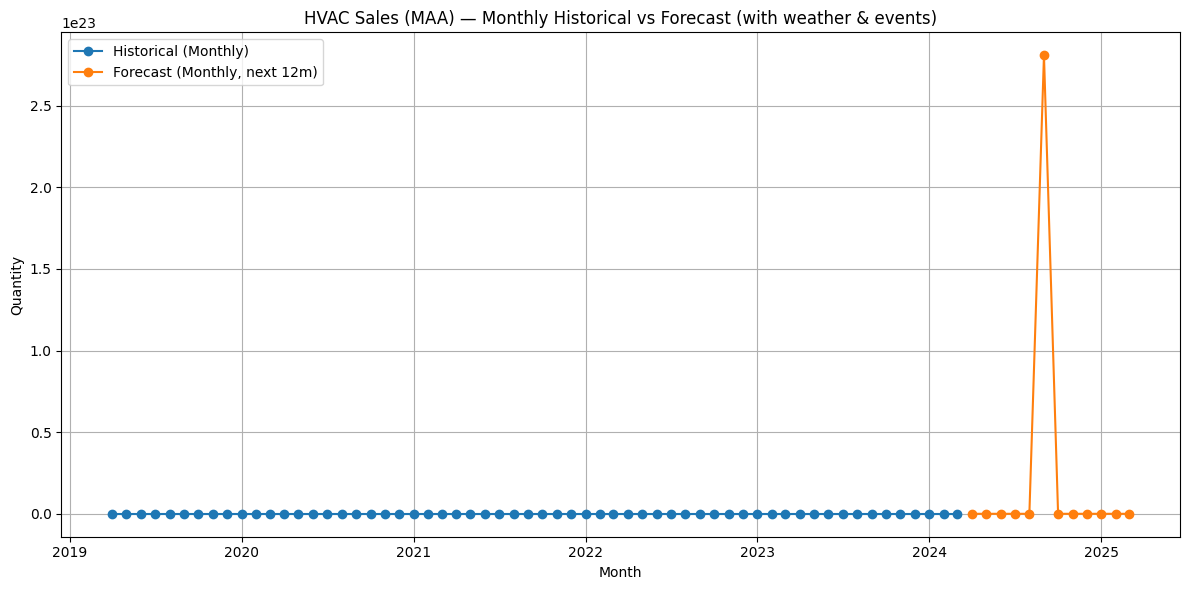

ModuleNotFoundError: No module named 'ace_tools'

In [4]:
# Monthly aggregated forecast using a SARIMAX (as a stand-in for NeuralProphet)
# with simulated weekly weather regressors and event flags, then aggregated to monthly totals.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings, math
warnings.filterwarnings("ignore")

# 1) Load weekly data
path = "../data/branch_wise_weekly.csv"
df = pd.read_csv(path, parse_dates=["Date"])
df = df[df["Branch"] == "MAA"][["Date","Quantity"]].sort_values("Date").reset_index(drop=True)

# Ensure weekly cadence (anchor to weekday of first date)
start = df["Date"].min()
weekday = start.weekday()
weekly_index = pd.date_range(start=start, end=df["Date"].max(), freq=pd.offsets.Week(weekday=weekday))
df = df.set_index("Date").reindex(weekly_index)
df.index.name = "Date"
# Use 0 for missing weeks (no sales recorded). For modeling, we'll keep as 0 but log1p later.
df["Quantity"] = df["Quantity"].fillna(0.0)

# 2) Simulated weekly weather regressors (Tamil Nadu-like seasonality)
# Temperature peaks in May-Jun; humidity peaks in Aug-Sep.
weeks = np.arange(len(df))
# Yearly seasonality (52 weeks): sine and cosine terms
yearly_phase = 2 * np.pi * (weeks % 52) / 52.0
temp = 30 + 6*np.sin(yearly_phase - np.pi/6)  # peak ~ May-Jun
humidity = 65 + 10*np.sin(yearly_phase + np.pi/3)  # peak ~ Aug-Sep
# Normalize to zero-mean for stability
temp_z = (temp - np.mean(temp)) / np.std(temp)
hum_z = (humidity - np.mean(humidity)) / np.std(humidity)

# 3) Event flags
months = pd.Series(df.index.month, index=df.index)
summer = months.isin([4,5,6]).astype(int)          # Apr-Jun
monsoon = months.isin([7,8,9]).astype(int)         # Jul-Sep
festival = months.isin([10,11,12]).astype(int)     # Oct-Dec

# Combine exog
exog = pd.DataFrame({
    "temp_z": temp_z,
    "hum_z": hum_z,
    "summer": summer.values,
    "monsoon": monsoon.values,
    "festival": festival.values
}, index=df.index)

# 4) Log-transform for variance stability
y = np.log1p(df["Quantity"].astype(float))

# 5) Fit SARIMAX with weekly seasonality & exogenous inputs (stand-in for NeuralProphet)
def fit_model(endog, exog):
    tried = []
    for order in [(1,0,1), (0,1,1), (1,1,0), (0,1,0)]:
        for seas in [(1,1,1,52), (0,1,1,52), (1,1,0,52), (0,1,0,52)]:
            try:
                model = SARIMAX(endog, order=order, seasonal_order=seas,
                                exog=exog, enforce_stationarity=False, enforce_invertibility=False)
                res = model.fit(disp=False, maxiter=200)
                return res, order, seas
            except Exception as e:
                tried.append((order, seas, str(e)))
                continue
    raise RuntimeError("All SARIMAX fits failed. Tried: " + str(tried[:3]) + " ...")

res, order_used, seas_used = fit_model(y, exog)

# 6) Build 52-week future exog on same weekly cadence
last_date = df.index[-1]
future_index = pd.date_range(start=last_date + pd.Timedelta(days=7), periods=52, freq=pd.offsets.Week(weekday=weekday))
weeks_future = np.arange(len(df), len(df)+len(future_index))
yearly_phase_f = 2 * np.pi * (weeks_future % 52) / 52.0
temp_f = 30 + 6*np.sin(yearly_phase_f - np.pi/6)
hum_f = 65 + 10*np.sin(yearly_phase_f + np.pi/3)
temp_fz = (temp_f - np.mean(temp)) / np.std(temp)  # standardize with its own mean/std
hum_fz = (hum_f - np.mean(hum_f)) / np.std(hum_f)

months_f = pd.Series(future_index.month, index=future_index)
summer_f = months_f.isin([4,5,6]).astype(int)
monsoon_f = months_f.isin([7,8,9]).astype(int)
festival_f = months_f.isin([10,11,12]).astype(int)

exog_f = pd.DataFrame({
    "temp_z": temp_fz,
    "hum_z": hum_fz,
    "summer": summer_f.values,
    "monsoon": monsoon_f.values,
    "festival": festival_f.values
}, index=future_index)

# 7) Forecast 52 weeks ahead
pred = res.get_forecast(steps=52, exog=exog_f)
pred_mean = np.expm1(pred.predicted_mean)  # back-transform
pred_ci = pred.conf_int()
# For intervals on original scale, approximate by transforming bounds
lower = np.expm1(pred_ci.iloc[:, 0])
upper = np.expm1(pred_ci.iloc[:, 1])

forecast_w = pd.DataFrame({
    "Date": future_index,
    "Forecast_Quantity": pred_mean.values,
    "Lower_CI": lower.values,
    "Upper_CI": upper.values
}).set_index("Date")

# 8) Aggregate to monthly totals (calendar month)
hist_monthly = df["Quantity"].resample("MS").sum().rename("Historical")
fcast_monthly = forecast_w["Forecast_Quantity"].resample("MS").sum().rename("Forecast")
lower_m = forecast_w["Lower_CI"].resample("MS").sum().rename("Lower_CI")
upper_m = forecast_w["Upper_CI"].resample("MS").sum().rename("Upper_CI")

monthly_df = pd.concat([fcast_monthly, lower_m, upper_m], axis=1).dropna().copy()
monthly_df["Forecast"] = monthly_df["Forecast"].round(1)
monthly_df["Lower_CI"] = monthly_df["Lower_CI"].round(1)
monthly_df["Upper_CI"] = monthly_df["Upper_CI"].round(1)

# 9) Plot monthly historical vs forecast
plt.figure(figsize=(12,6))
plt.plot(hist_monthly.index, hist_monthly.values, label="Historical (Monthly)", marker='o')
plt.plot(monthly_df.index, monthly_df["Forecast"], label="Forecast (Monthly, next 12m)", marker='o')
plt.title("HVAC Sales (MAA) — Monthly Historical vs Forecast (with weather & events)")
plt.xlabel("Month")
plt.ylabel("Quantity")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 10) Save output CSVs for download
monthly_out = monthly_df.reset_index().rename(columns={"index":"Month"})
weekly_out = forecast_w.reset_index()

monthly_path = "../data/MAA_monthly_forecast_12m_with_weather.csv"
weekly_path = "../data/MAA_weekly_forecast_52w_with_weather.csv"
monthly_out.to_csv(monthly_path, index=False)
weekly_out.to_csv(weekly_path, index=False)

# Show monthly forecast to user in a table and print model details
import ace_tools as tools
tools.display_dataframe_to_user("Monthly HVAC Forecast (MAA) — Next 12 months", monthly_out)

print("Model used (stand-in for NeuralProphet): SARIMAX")
print("Order:", order_used, "Seasonal:", seas_used)
print("Saved files:")
print(" - Monthly forecast:", monthly_path)
print(" - Weekly forecast:", weekly_path)
